In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif']= 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus']= False

In [2]:
data=pd.read_excel(r"D:\编程教程\Python-projects\data-analysis\餐饮经营分析：起死回生的奶茶店.xlsx")
data

,年份,2018年,2019年,2020年,2021年,2022年,2023年
0,截止年底，直营店数量（个）,2073.00,4507.00,3929.00,4397.0,5652.0,10628.0
1,截止年底，加盟店数量（个）,0.00,282.00,874.00,1627.0,2562.0,5620.0
2,总门店数（个）,2073.00,4789.00,4803.00,6024.0,8214.0,16248.0
3,截止年底，用户数（万）,432.50,1158.81,971.21,1622.9,2455.9,6243.8
4,产品销售收入（万）,84069.50,300959.00,371679.10,665921.8,1022372.0,1867739.0
5,合作店收入（万）,0.00,1534.40,31662.70,130610.5,306926.2,622577.6
6,总收入（万）,84069.50,302493.40,403341.80,796532.3,1329298.2,2490316.6
7,材料成本（万）,-53221.70,-162332.40,-199538.00,-319855.2,-517896.3,-1089221.4
8,直营店租金及运营费用（万）,-67403.80,-166874.80,-173660.10,-205312.4,-286599.9,-527716.7
9,折旧与摊销费用（万）,-10669.00,-41188.30,-48342.10,-46538.4,-39193.6,-60458.0


In [3]:
pd.set_option("display.float_format",'{:.2f}'.format)
data=data.T.reset_index()
#使用用的第一行值为新的列名
data.columns=data.iloc[0,:]
#删除第一行
data=data.iloc[1:,:]
data

,年份,截止年底，直营店数量（个）,截止年底，加盟店数量（个）,总门店数（个）,截止年底，用户数（万）,产品销售收入（万）,合作店收入（万）,总收入（万）,材料成本（万）,直营店租金及运营费用（万）,折旧与摊销费用（万）,配送费用（万）,销售与市场费用（万）,一般管理费用（万）,财务相关费用（万）,总运营费用（万）,运营亏损（万）,其他收支（万）,净利润（万）
1,2018年,2073.00,0.00,2073.00,432.50,84069.50,0.00,84069.50,-53221.70,-67403.80,-10669.00,-26110.63,-48491.17,-37973.80,0.00,-243870.10,-159800.60,-2114.60,-161915.20
2,2019年,4507.00,282.00,4789.00,1158.81,300959.00,1534.40,302493.40,-162332.40,-166874.80,-41188.30,-43891.40,-81259.20,-107233.90,-20924.90,-623704.90,-321211.50,5160.80,-316050.70
3,2020年,3929.00,874.00,4803.00,971.21,371679.10,31662.70,403341.80,-199538.00,-173660.10,-48342.10,-41480.80,-46211.20,-98164.50,-54671.90,-662068.60,-258726.80,-301572.20,-560299.00
4,2021年,4397.00,1627.00,6024.00,1622.90,665921.80,130610.50,796532.30,-319855.20,-205312.40,-46538.40,-81954.90,-33685.50,-126998.80,-36092.50,-850437.70,-53905.40,111770.70,57865.30
5,2022年,5652.00,2562.00,8214.00,2455.90,1022372.00,306926.20,1329298.20,-517896.30,-286599.90,-39193.60,-137321.90,-57012.20,-145955.00,-29701.40,-1213680.30,115617.90,-66793.30,48824.60
6,2023年,10628.00,5620.00,16248.00,6243.80,1867739.00,622577.60,2490316.60,-1089221.40,-527716.70,-60458.00,-201069.90,-128652.30,-182965.10,2328.60,-2187754.80,302561.80,-17768.50,284793.30


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 1 to 6
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   年份             6 non-null      object
 1   截止年底，直营店数量（个）  6 non-null      object
 2   截止年底，加盟店数量（个）  6 non-null      object
 3   总门店数（个）        6 non-null      object
 4   截止年底，用户数（万）    6 non-null      object
 5   产品销售收入（万）      6 non-null      object
 6   合作店收入（万）       6 non-null      object
 7   总收入（万）         6 non-null      object
 8   材料成本（万）        6 non-null      object
 9   直营店租金及运营费用（万）  6 non-null      object
 10  折旧与摊销费用（万）     6 non-null      object
 11  配送费用（万）        6 non-null      object
 12  销售与市场费用（万）     6 non-null      object
 13  一般管理费用（万）      6 non-null      object
 14  财务相关费用（万）      6 non-null      object
 15  总运营费用（万）       6 non-null      object
 16  运营亏损（万）        6 non-null      object
 17  其他收支（万）        6 non-null      object
 18  净利润（万）         6 non-null      obj

In [4]:
for col in data.columns[1:]:
    data[col]=pd.to_numeric(data[col],errors='coerce')

In [5]:
data.dtypes

0
年份                object
截止年底，直营店数量（个）    float64
截止年底，加盟店数量（个）    float64
总门店数（个）          float64
截止年底，用户数（万）      float64
产品销售收入（万）        float64
合作店收入（万）         float64
总收入（万）           float64
材料成本（万）          float64
直营店租金及运营费用（万）    float64
折旧与摊销费用（万）       float64
配送费用（万）          float64
销售与市场费用（万）       float64
一般管理费用（万）        float64
财务相关费用（万）        float64
总运营费用（万）         float64
运营亏损（万）          float64
其他收支（万）          float64
净利润（万）           float64
dtype: object

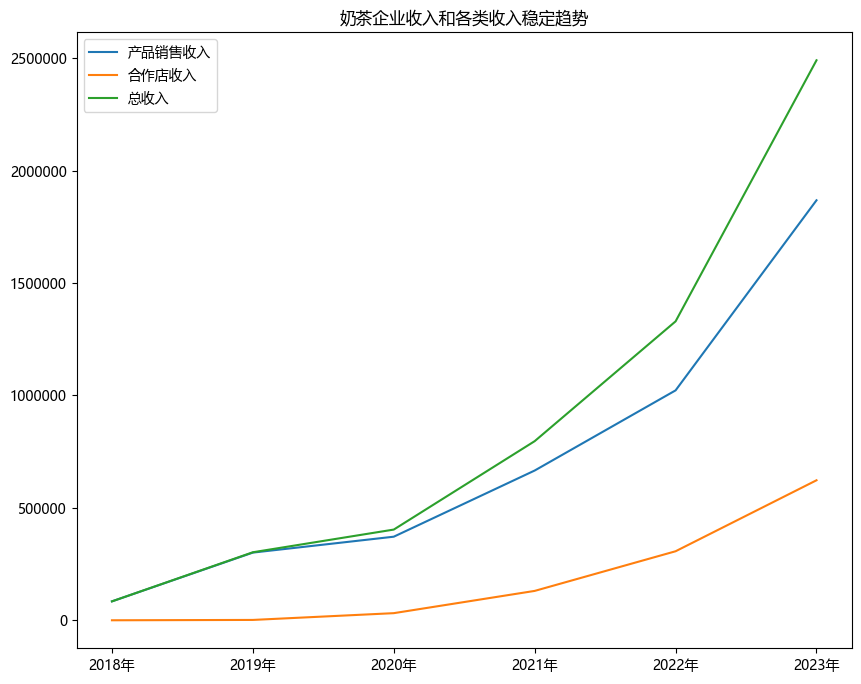

In [8]:
# 总收入和产品销售收入
plt.figure(figsize=(10,8))
x1=data["年份"]
y1=data["产品销售收入（万）"]
y3=data["总收入（万）"]
y2=data["合作店收入（万）"]
plt.plot(x1,y1,label='产品销售收入')
plt.plot(x1,y2,label='合作店收入')
plt.plot(x1,y3,label='总收入')
plt.title('奶茶企业收入和各类收入稳定趋势')
plt.legend()
plt.ticklabel_format(style='plain',axis='y')
plt.show()